In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/augdatasetusingst1/st1_aug_full_label1.csv
/kaggle/input/augdatasetusingst1/augmented_data_label0.csv
/kaggle/input/augdatasetusingst1/st1.csv
/kaggle/input/augdatasetusingst1/augmented_data_label1.csv
/kaggle/input/augtestafri/aug_multilabel_hau_test_light_v2_expanded_v2.csv
/kaggle/input/augtestafri/aug_multilabel_light_v3.csv
/kaggle/input/augtestafri/aug_multilabel_hau_test_light_v2_expanded.csv
/kaggle/input/augtestafri/aug_multilabel_hau_test_light_v2.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/tel.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/mya.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/amh.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/eng.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/ben.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/hau.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/khm.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/pan.csv
/kaggle/input/update-ds-semeval2026/subtask2/test/pol.cs

In [2]:
df_train = pd.read_csv("/kaggle/input/update-ds-semeval2026/subtask1/train/hau.csv")
df_dev = pd.read_csv("/kaggle/input/update-ds-semeval2026/subtask1/dev/hau.csv")
df_test = pd.read_csv("/kaggle/input/update-ds-semeval2026/subtask1/test/hau.csv")

In [3]:
import pandas as pd
import re
import emoji

def clean_text(text):
    # 1. Chuyển về lowercase (tùy model bạn chọn)
    # text = text.lower()
    
    # 2. Xử lý HTML entities
    text = re.sub(r'&amp;', '&', text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    # 3. Thay thế các cấu trúc đặc biệt của dataset
    text = text.replace("##url", "[URL]")
    text = re.sub(r'@user', '[USER]', text)
    
    # # 5. Xóa các ký tự lạ, giữ lại dấu câu quan trọng (?, !)
    # # Lưu ý: Giữ lại các ký tự đặc biệt của tiếng Hausa: ɓ, ɗ, ƙ, ƴ
    # text = re.sub(r"[^a-z0-9ɓɗƙƴ\s\!\?\.]", " ", text)
    
    # 6. Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [4]:
df_train['text'] = df_train['text'].apply(clean_text)
df_dev['text'] = df_dev['text'].apply(clean_text)
# Áp dụng cho tập Anh (đã lọc polarization)
df_test['text'] = df_test['text'].apply(clean_text)

In [5]:
df_train.shape

(3651, 3)

tokenizer_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (730 > 512). Running this sequence through the model will result in indexing errors


count    3651.000000
mean       42.579019
std        36.249946
min         1.000000
50%        35.000000
90%        83.000000
95%        96.000000
99%       117.500000
max      1189.000000
Name: token_length, dtype: float64


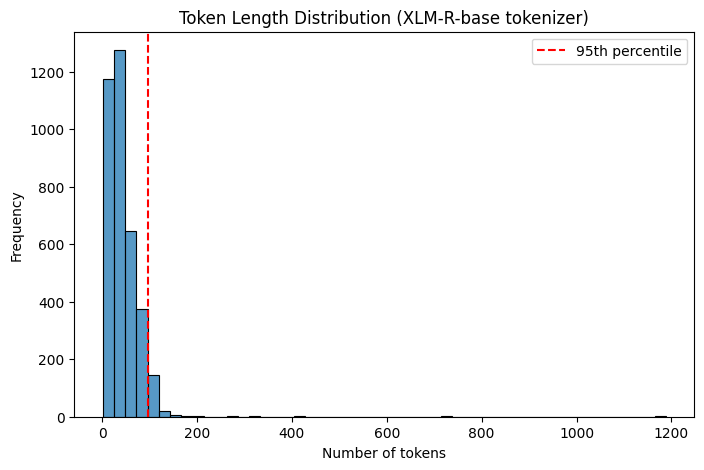

In [6]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
# 3. Distribution of text lengths (in tokens)
tokenizer = AutoTokenizer.from_pretrained("Davlan/bert-base-multilingual-cased-finetuned-hausa")
df_train["token_length"] = df_train["text"].apply(lambda x: len(tokenizer.tokenize(str(x))))

# Summary stats
print(df_train["token_length"].describe(percentiles=[.5, .9, .95, .99]))

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df_train["token_length"], bins=50, kde=False)
plt.axvline(df_train["token_length"].quantile(0.95), color='red', linestyle='--', label='95th percentile')
plt.title("Token Length Distribution (XLM-R-base tokenizer)")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [7]:
# import thư viện
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

2026-02-28 07:16:14.404744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772262974.593149      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772262974.644362      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772262975.098719      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772262975.098760      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772262975.098763      24 computation_placer.cc:177] computation placer alr

In [8]:
df_1 = pd.read_csv("/kaggle/input/augtestafri/aug_multilabel_hau_test_light_v2_expanded_v2.csv")
df_2 = pd.read_csv("/kaggle/input/augtestafri/aug_multilabel_hau_test_light_v2_expanded.csv")
df_3 = pd.read_csv("/kaggle/input/augtestafri/aug_multilabel_hau_test_light_v2.csv")
# Danh sách các cột thành phần
sub_labels = ['political', 'racial/ethnic', 'religious', 'gender/sexual', 'other']

# Nếu bất kỳ cột nào trong sub_labels có giá trị là 1, thì polarization = 1
df_3['polarization'] = df_3[sub_labels].max(axis=1)
df_3['text'] = df_3['text'].apply(clean_text)

# Kiểm tra kết quả
print(df_3[['text', 'polarization']].head())

                                                text  polarization
0  An gano manyan kura-kurai a tsarin mulkin sabu...             1
1  Wannan gwamnati tana da corrupt abin kunya! Su...             1
2  An yi zargin an sayi kuri'u a zaben yankin Are...             1
3  Barawo ne kawai zai goyi bayan wannan leadersh...             1
4  Kotu ta dage sauraron karar cin hanci da rasha...             1


In [9]:
df_1.shape

(2481, 8)

In [10]:
df_2.shape

(1981, 8)

In [11]:
df_3.shape

(1431, 9)

In [12]:
df_3["polarization"].value_counts()

polarization
1    1431
Name: count, dtype: int64

In [13]:
df_train["polarization"].value_counts()

polarization
0    3259
1     392
Name: count, dtype: int64

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Split tập dữ liệu Hausa gốc (80% Train, 20% Val)
# df_aug = df_aug.sample(n=, random_state=42)

train_hau, val_hau = train_test_split(
    df_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_train['polarization']
)

# 2. Split tập Augmentation (Ví dụ: 80% đưa vào Train, 20% đưa vào Val)
# Việc dùng stratify ở đây giúp tập Val-aug có đủ cả các nhãn phân cực
train_aug, val_aug = train_test_split(
    df_3,
    test_size=0.2,
    random_state=42,
    stratify=df_3['label_combo']
)

# 3. Nối các tập lại thành tập cuối cùng
# Tập Train bao gồm: Hausa gốc + Aug-train + English (Polarized only)
train = pd.concat([train_hau, df_3], ignore_index=True)
# train = train_hau
# Tập Val bao gồm: Hausa gốc + Aug-val
# val = pd.concat([val_hau, val_aug], ignore_index=True)
val = val_hau

# 4. Xáo trộn dữ liệu để mô hình không học theo thứ tự nối
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
val = val.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Số lượng mẫu tập Train: {len(train)}")
print(f"Số lượng mẫu tập Val: {len(val)}")

Số lượng mẫu tập Train: 4351
Số lượng mẫu tập Val: 731


In [15]:
train["polarization"].value_counts()

polarization
0    2606
1    1745
Name: count, dtype: int64

In [16]:
val["polarization"].value_counts()

polarization
0    653
1     78
Name: count, dtype: int64

In [17]:
# config model 
# MODEL_NAME = "Davlan/afro-xlmr-large"
MODEL_NAME = "Davlan/xlm-roberta-base-finetuned-hausa"
# MODEL_NAME = "FacebookAI/xlm-roberta-base"
# MODEL_NAME = "castorini/afriberta_large"
NUM_LABELS = 2
MAX_LEN = 128
LR = 2e-5
WEIGHT_DECAY = 0.06
EPOCHS = 5
TRAIN_BS = 12     
EVAL_BS = 16
WARMUP_RATIO = 0.06
SEED = 42
OUTPUT_DIR = "./model_output/"

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# tạo dataset class
class PolarizationDataset(Dataset):
    def __init__(self, df, tokenizer, max_len: int, is_test: bool = True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row['text']
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        if not self.is_test:
            label = row['polarization']
            item['labels'] = torch.tensor(label, dtype=torch.long)
        return item


# khởi tạo tokenizer và dataset
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset = PolarizationDataset(train, tokenizer, MAX_LEN, is_test=False)
val_dataset = PolarizationDataset(val, tokenizer, MAX_LEN, is_test=False)
data_collator = DataCollatorWithPadding(tokenizer)


# Use class weights
# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=np.unique(df_train['polarization']),
#     y=df_train['polarization'].values
# )
# class_weights = torch.tensor(weights, dtype=torch.float).to(device)

# class WeightedRoberta(nn.Module):
#     def __init__(self, model_name, num_labels, weights):
#         super().__init__()
#         self.model = AutoModelForSequenceClassification.from_pretrained(
#             model_name, 
#             num_labels=num_labels,
#             hidden_dropout_prob=0.1,
#             attention_probs_dropout_prob=0.1
#         )
#         self.loss_fn = nn.CrossEntropyLoss(weight=weights)

#     def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
#         # FIX: Loại bỏ 'num_items_in_batch' khỏi kwargs trước khi đưa vào RoBERTa
#         kwargs.pop("num_items_in_batch", None)
        
#         outputs = self.model(
#             input_ids=input_ids, 
#             attention_mask=attention_mask, 
#             **kwargs
#         )
        
#         logits = outputs.logits
#         loss = None
#         if labels is not None:
#             loss = self.loss_fn(logits, labels)
        
#         return SequenceClassifierOutput(loss=loss, logits=logits)
# model = WeightedRoberta(MODEL_NAME, NUM_LABELS, class_weights).to(device)

# Khởi tạo model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=NUM_LABELS,
    hidden_dropout_prob=0.2,         
    attention_probs_dropout_prob=0.2
).to(device)

# định nghĩa hàm tính metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        'f1_weighted': f1_score(labels, preds, average='weighted'),
        'f1_macro': f1_score(labels, preds, average='macro'), 
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall': recall_score(labels, preds, average='weighted', zero_division=0)
    }

# Thiết lập tham số huấn luyện
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",     
    greater_is_better=True,
    fp16=torch.cuda.is_available(),        
    save_total_limit=4,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

tokenizer_config.json:   0%|          | 0.00/356 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at Davlan/xlm-roberta-base-finetuned-hausa and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_24/4155005756.py:138: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [18]:
# huấn luyện mô hình
trainer.train()

# lưu mô hình
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,F1 Weighted,F1 Macro,Precision,Recall
1,0.292500,0.295567,0.944967,0.854839,0.944684,0.945280
2,0.190000,0.295965,0.937159,0.831857,0.936255,0.938440
3,0.169300,0.306321,0.940315,0.841216,0.939646,0.941176
4,0.150300,0.292489,0.935958,0.829136,0.935116,0.937073
5,0.125200,0.332218,0.933960,0.825807,0.933613,0.934337


('./model_output/tokenizer_config.json',
 './model_output/special_tokens_map.json',
 './model_output/sentencepiece.bpe.model',
 './model_output/added_tokens.json',
 './model_output/tokenizer.json')

In [19]:
print("Best metric:", trainer.state.best_metric)
print("Best checkpoint:", trainer.state.best_model_checkpoint)

Best metric: 0.8548393502521943
Best checkpoint: ./model_output/checkpoint-363


In [20]:
model = AutoModelForSequenceClassification.from_pretrained(OUTPUT_DIR)
tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
model.to(device)
model.eval()

# Lưu toàn bộ trọng số của lớp wrapper WeightedRoberta
# torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "weighted_roberta.pt"))

# # Tokenizer thì vẫn lưu bằng cách cũ vì nó đã chạy đúng
# tokenizer.save_pretrained(OUTPUT_DIR)

# print(f"Đã lưu trọng số tại: {OUTPUT_DIR}/weighted_roberta.pt")

# # 1. Khởi tạo khung model trống (phải có class WeightedRoberta trong code)
# model = WeightedRoberta(MODEL_NAME, NUM_LABELS, class_weights)

# # 2. Đổ trọng số đã lưu vào khung
# model.load_state_dict(torch.load(f"{OUTPUT_DIR}/weighted_roberta.pt", map_location=device))
# model.to(device)
# model.eval()

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.2, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [21]:
import torch
import numpy as np
test_texts = [
    # 1. Xúc phạm trí tuệ cá nhân (Dakiki - Kẻ đần độn)
    "@USER dakiki ne kawai, bai san abin da yake fada ba, gara ya yi shiru.",
    # Dịch: @USER chỉ là một kẻ đần độn, anh ta chẳng biết mình đang nói cái gì cả, tốt nhất là nên im miệng lại.

    # 2. Xúc phạm lối sống/tính cách (Malalaci - Kẻ lười biếng)
    "Kai malalaci ne, kullum sai dai ka jira a baka amma ba ka son aiki, asararre kawai.",
    # Dịch: Mày là đồ lười biếng, suốt ngày chỉ đợi người khác dâng tận miệng chứ không chịu làm việc, đúng là kẻ vô dụng.

    # 3. Xúc phạm ngoại hình/vệ sinh (Xúc phạm trực diện cá nhân)
    "@USER dubi fuskarka kamar wanda bai taba wanka ba, ka daina damunmu da surutunka.",
    # Dịch: @USER nhìn mặt anh kìa, trông như cả đời chưa bao giờ tắm ấy, đừng có làm phiền chúng tôi bằng mấy lời nhảm nhí đó nữa.

    # 4. Cáo buộc dối trá cá nhân (Makaryaci - Kẻ nói dối)
    "@USER makaryaci ne, kowa ya sani ba a taba dogara da kai ba tun muna yara.",
    # Dịch: @USER là một kẻ dối trá, ai cũng biết là chẳng bao giờ có thể tin tưởng được mày từ khi chúng ta còn bé rồi.

    # 5. Chửi bới cá nhân bằng từ ngữ thô tục thông thường (Wawa - Thằng ngốc)
    "Wannan wawa ne kawai, ba shi da hankali ko kadan, kar ku saurare shi.",
    # Dịch: Thằng này chỉ là một tên ngốc, nó chẳng có chút trí khôn nào cả, mọi người đừng có nghe nó nói.
    "fuck putin, all my homie hate putin"
]
model.eval()

for idx, text in enumerate(test_texts, 1):
    # Tokenize
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=192,
        return_tensors="pt"
    ).to(device)

    # Inference
    with torch.inference_mode():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred_label = np.argmax(probs)

    # Print result
    print("=" * 80)
    print(f"[{idx}] Text: {text}")
    print(f"Probabilities: {probs}")
    print(f"Predicted label: {pred_label}")


[1] Text: @USER dakiki ne kawai, bai san abin da yake fada ba, gara ya yi shiru.
Probabilities: [0.9951232  0.00487677]
Predicted label: 0
[2] Text: Kai malalaci ne, kullum sai dai ka jira a baka amma ba ka son aiki, asararre kawai.
Probabilities: [6.4916565e-04 9.9935085e-01]
Predicted label: 1
[3] Text: @USER dubi fuskarka kamar wanda bai taba wanka ba, ka daina damunmu da surutunka.
Probabilities: [0.99798137 0.0020186 ]
Predicted label: 0
[4] Text: @USER makaryaci ne, kowa ya sani ba a taba dogara da kai ba tun muna yara.
Probabilities: [0.9885318  0.01146818]
Predicted label: 0
[5] Text: Wannan wawa ne kawai, ba shi da hankali ko kadan, kar ku saurare shi.
Probabilities: [7.8465254e-04 9.9921536e-01]
Predicted label: 1
[6] Text: fuck putin, all my homie hate putin
Probabilities: [0.9982199  0.00178007]
Predicted label: 0


In [22]:
df_dev = pd.read_csv("/kaggle/input/update-ds-semeval2026/subtask1/dev/hau.csv")
df_test = pd.read_csv("/kaggle/input/update-ds-semeval2026/subtask1/test/hau.csv")

In [23]:
df_dev['text'] = df_dev['text'].apply(clean_text)
# Áp dụng cho tập Anh (đã lọc polarization)
df_test['text'] = df_test['text'].apply(clean_text)

In [24]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix

# 1. Đánh giá trên tập dev Hausa (đã có nhãn gold)
print("=== Evaluating on Hausa Dev set (Gold Labels) ===")

# Đảm bảo bạn đã có df_dev_hau (DataFrame chứa dữ liệu tiếng Hausa)
# và tokenizer phù hợp (thường là đa ngôn ngữ như XLM-R hoặc AfroXML-R)
dev_dataset_hau = PolarizationDataset(df_dev, tokenizer, MAX_LEN, is_test=False)

# Chạy dự đoán
dev_output_hau = trainer.predict(dev_dataset_hau)

# Lấy nhãn dự đoán và nhãn thực tế
dev_labels_hau = dev_output_hau.label_ids
# dev_output_hau.predictions có thể là tuple (logits, hidden_states), ta lấy [0] nếu cần
preds_logits = dev_output_hau.predictions[0] if isinstance(dev_output_hau.predictions, tuple) else dev_output_hau.predictions
dev_preds_hau = np.argmax(preds_logits, axis=1)

# Tính toán các chỉ số
hau_f1_macro = f1_score(dev_labels_hau, dev_preds_hau, average='macro')
hau_precision = precision_score(dev_labels_hau, dev_preds_hau, average='weighted', zero_division=0)
hau_recall = recall_score(dev_labels_hau, dev_preds_hau, average='weighted', zero_division=0)
hau_accuracy = accuracy_score(dev_labels_hau, dev_preds_hau)

print(f"\nHausa Dev Metrics Result:")
print(f" - F1 Macro: {hau_f1_macro:.4f}")
print(f" - Precision: {hau_precision:.4f}")
print(f" - Recall: {hau_recall:.4f}")
print(f" - Accuracy: {hau_accuracy:.4f}")

# Kiểm tra Confusion Matrix
print("\nConfusion Matrix (Hausa):")
cm_hau = confusion_matrix(dev_labels_hau, dev_preds_hau)
print(cm_hau)

# ====== Save Hausa Dev results ======
submission_dev_hau = pd.DataFrame({
    "id": df_dev["id"],
    "polarization": dev_preds_hau,
})

# Đổi tên file thành pred_hau_dev.csv
hau_output_path = os.path.join(OUTPUT_DIR, "pred_hau_dev.csv")
submission_dev_hau.to_csv(hau_output_path, index=False)

print(f"\n✅ Đã xuất file kết quả Hausa Dev tại: {hau_output_path}")

=== Evaluating on Hausa Dev set (Gold Labels) ===



Hausa Dev Metrics Result:
 - F1 Macro: 0.8190
 - Precision: 0.9306
 - Recall: 0.9231
 - Accuracy: 0.9231

Confusion Matrix (Hausa):
[[153   9]
 [  5  15]]

✅ Đã xuất file kết quả Hausa Dev tại: ./model_output/pred_hau_dev.csv


In [25]:
# 2. Dự đoán trên tập test (để submit)
print("\n=== Predicting on Test set for submission ===")
test_dataset = PolarizationDataset(df_test, tokenizer, MAX_LEN, is_test=True) # is_test=True vì chưa có nhãn
test_output = trainer.predict(test_dataset)

test_logits = test_output.predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_preds = np.argmax(test_probs, axis=1)

# ====== Save results ======
submission = pd.DataFrame({
    "id": df_test["id"],
    "polarization": test_preds,
})
submission.to_csv(os.path.join(OUTPUT_DIR, "pred_hau.csv"), index=False)

submission_probs = pd.DataFrame({
    "id": df_test["id"],
    "prob_class1": test_probs[:, 1],
})
submission_probs.to_csv(os.path.join(OUTPUT_DIR, "pred_hau_probs.csv"), index=False)

print(f"Saved submission file to: {os.path.join(OUTPUT_DIR, 'pred_hau.csv')}")


=== Predicting on Test set for submission ===


Saved submission file to: ./model_output/pred_hau.csv
